In [ ]:
from google.colab import files


uploaded = files.upload()

Saving Forest Fire Dataset.zip to Forest Fire Dataset.zip


In [ ]:
import zipfile
import os


zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Extraction completed!")

print("Extracted folders:", os.listdir("data"))

Extraction completed!
Extracted folders: ['Forest Fire Dataset']


In [ ]:
for root, dirs, files in os.walk("data"):
    level = root.replace("data", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

data/
    Forest Fire Dataset/
        Training/
            fire/
                fire_0127.jpg
                fire_0233.jpg
                fire_0241.jpg
                fire_0074.jpg
                fire_0561.jpg
                fire_0220.jpg
                fire_0443.jpg
                fire_0024.jpg
                fire_0950.jpg
                fire_0373.jpg
                fire_0844.jpg
                fire_0550.jpg
                fire_0401.jpg
                fire_0923.jpg
                fire_0119.jpg
                fire_0057.jpg
                fire_0114.jpg
                fire_0321.jpg
                fire_0330.jpg
                fire_0662.jpg
                fire_0590.jpg
                fire_0336.jpg
                fire_0457.jpg
                fire_0264.jpg
                fire_0172.jpg
                fire_0531.jpg
                fire_0168.jpg
                fire_0543.jpg
                fire_0481.jpg
                fire_0062.jpg
                fire_0378.jpg
   

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/Forest Fire Dataset/Training"
test_dir = "data/Forest Fire Dataset/Testing"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 1520 images belonging to 2 classes.
Found 379 images belonging to 2 classes.


In [ ]:
!pip install pillow

In [ ]:
import os
import hashlib
from PIL import Image

def remove_duplicate_images(folder_path):

    hashes = {}
    duplicates = []

    for root, _, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img = img.convert("RGB")
                    img_hash = hashlib.md5(img.tobytes()).hexdigest()

                    if img_hash in hashes:
                        print(f"Duplicate found: {file_path} --> Removing")
                        os.remove(file_path)
                        duplicates.append(file_path)
                    else:
                        hashes[img_hash] = file_path
            except Exception as e:
                print(f"Skipping {file_path}, error: {e}")

    print(f"\n✅ Done! Removed {len(duplicates)} duplicate images.")
    return duplicates

In [ ]:
train_dir = "data/Forest Fire Dataset/Training"
test_dir = "data/Forest Fire Dataset/Testing"

print("Checking Training folder for duplicates...")
remove_duplicate_images(train_dir)

print("\nChecking Testing folder for duplicates...")
remove_duplicate_images(test_dir)

Checking Training folder for duplicates...

✅ Done! Removed 0 duplicate images.

Checking Testing folder for duplicates...

✅ Done! Removed 0 duplicate images.


[]

In [ ]:
import os
from PIL import Image

def remove_corrupted_images(folder_path):

    corrupted = []

    for root, _, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()

            except (IOError, SyntaxError) as e:
                print(f"❌ Corrupted image found and removed: {file_path}")
                os.remove(file_path)
                corrupted.append(file_path)

    print(f"\n✅ Done! Removed {len(corrupted)} corrupted images.")
    return corrupted

In [ ]:
train_dir = "data/Forest Fire Dataset/Training"
test_dir = "data/Forest Fire Dataset/Testing"

print("Checking Training folder for corrupted images...")
remove_corrupted_images(train_dir)

print("\nChecking Testing folder for corrupted images...")
remove_corrupted_images(test_dir)

Checking Training folder for corrupted images...

✅ Done! Removed 0 corrupted images.

Checking Testing folder for corrupted images...

✅ Done! Removed 0 corrupted images.


[]

Class: fire, Images: 760
Class: nofire, Images: 760


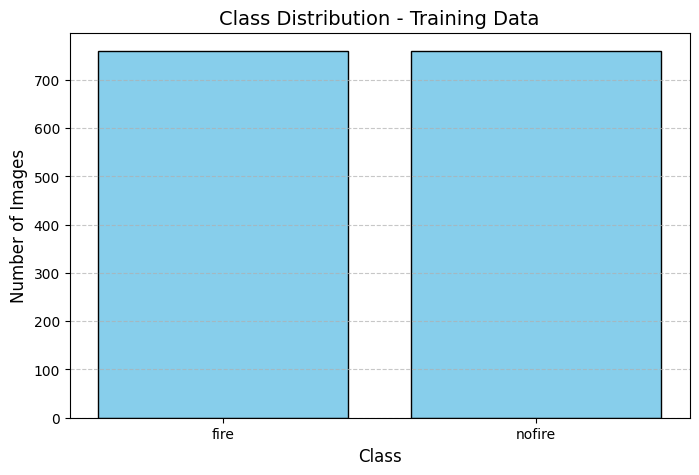

In [ ]:
import os
import glob
import matplotlib.pyplot as plt

train_dir = "data/Forest Fire Dataset/Training"

classes = os.listdir(train_dir)

counts = []

for c in classes:
    jpg_count = len(glob.glob(os.path.join(train_dir, c, "*.jpg")))
    jpeg_count = len(glob.glob(os.path.join(train_dir, c, "*.jpeg")))
    png_count = len(glob.glob(os.path.join(train_dir, c, "*.png")))

    total = jpg_count + jpeg_count + png_count
    counts.append(total)

    print(f"Class: {c}, Images: {total}")

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.title("Class Distribution - Training Data", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Class indices:", train_generator.class_indices)

Class indices: {'fire': 0, 'nofire': 1}


In [ ]:
import os
from PIL import Image

resize_size = (64, 64)
train_folder = "data/Forest Fire Dataset/Training"
test_folder = "data/Forest Fire Dataset/Testing"
def resize_images(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img = img.convert("RGB")
                img = img.resize(resize_size)
                img.save(file_path)
            except Exception as e:
                print(f"Error resizing {file_path}: {e}")

print("🔄 Resizing Training images...")
resize_images(train_folder)
print("✅ Training images resized successfully!")

print("🔄 Resizing Testing images...")
resize_images(test_folder)
print("✅ Testing images resized successfully!")

🔄 Resizing Training images...
✅ Training images resized successfully!
🔄 Resizing Testing images...
✅ Testing images resized successfully!


In [ ]:
import os
from PIL import Image

train_folder = "data/Forest Fire Dataset/Training"
test_folder = "data/Forest Fire Dataset/Testing"

def convert_to_grayscale(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img = img.convert('L')
                img.save(file_path)
            except Exception as e:
                print(f"Error converting to grayscale: {file_path} -> {e}")

print("🔄 Converting Training images to grayscale...")
convert_to_grayscale(train_folder)
print("✅ Training images converted to grayscale successfully!")

print("🔄 Converting Testing images to grayscale...")
convert_to_grayscale(test_folder)
print("✅ Testing images converted to grayscale successfully!")

🔄 Converting Training images to grayscale...
✅ Training images converted to grayscale successfully!
🔄 Converting Testing images to grayscale...
✅ Testing images converted to grayscale successfully!


Classes found: ['fire', 'nofire']


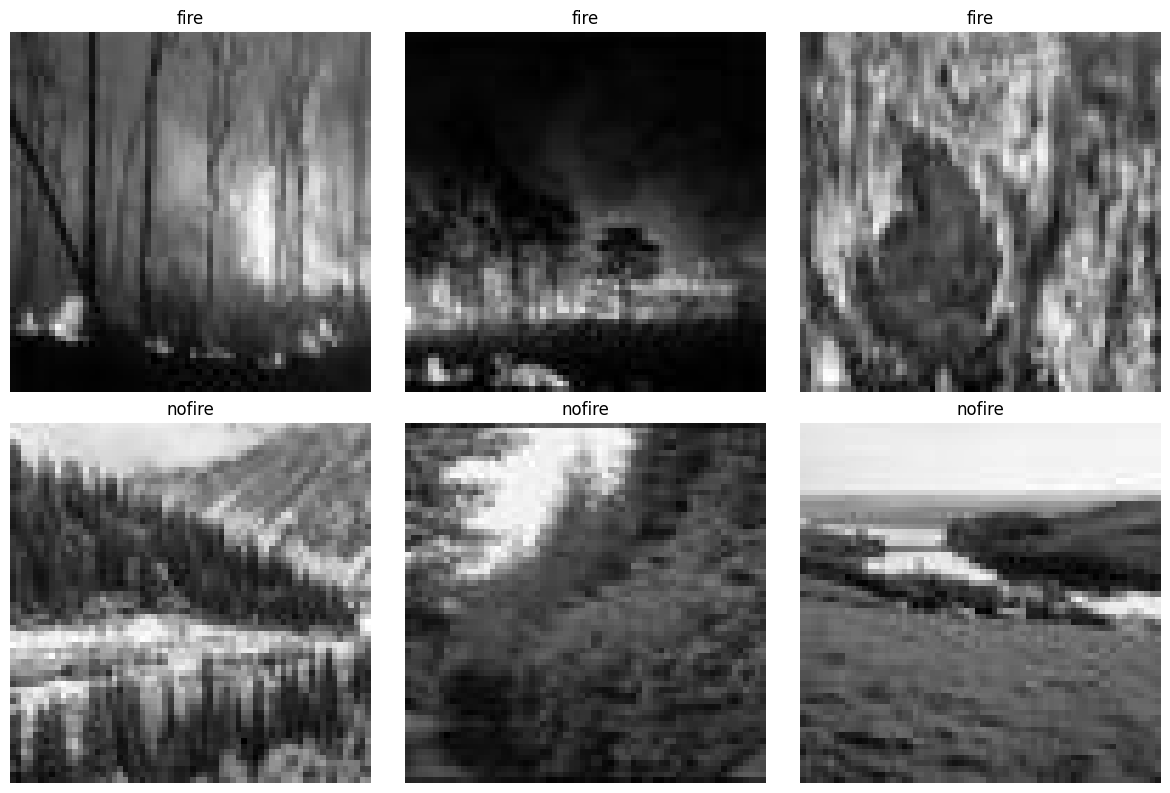

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from PIL import Image

def show_grayscale_images_by_class(folder_path, num_images_per_class=3):
    """
    Display grayscale images from each class (subfolder) in the dataset.
    """
    classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
    print(f"Classes found: {classes}")

    plt.figure(figsize=(12, 4 * len(classes)))

    for idx, cls in enumerate(classes):
        cls_folder = os.path.join(folder_path, cls)
        image_files = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]

        if not image_files:
            print(f"No images found in class '{cls}'")
            continue

        sample_files = random.sample(image_files, min(num_images_per_class, len(image_files)))

        for j, file in enumerate(sample_files):
            img_path = os.path.join(cls_folder, file)
            img = Image.open(img_path).convert('L')
            img_array = np.array(img)

            plt.subplot(len(classes), num_images_per_class, idx * num_images_per_class + j + 1)
            plt.imshow(img_array, cmap='gray')
            plt.title(f"{cls}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

train_folder = "data/Forest Fire Dataset/Training"
show_grayscale_images_by_class(train_folder)

In [ ]:
import os
import numpy as np
from PIL import Image

# Paths to your dataset folders
train_folder = "data/Forest Fire Dataset/Training"
test_folder = "data/Forest Fire Dataset/Testing"

def normalize_images(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    img = Image.open(file_path).convert('L')
                    img_array = np.array(img, dtype=np.float32)
                    img_array = img_array / 255.0
                    img_normalized = Image.fromarray((img_array * 255).astype(np.uint8))
                    img_normalized.save(file_path)
                except Exception as e:
                    print(f"Error normalizing {file_path}: {e}")

print("🔄 Normalizing Training images...")
normalize_images(train_folder)
print("✅ Training images normalized successfully!")

print("🔄 Normalizing Testing images...")
normalize_images(test_folder)
print("✅ Testing images normalized successfully!")

🔄 Normalizing Training images...
✅ Training images normalized successfully!
🔄 Normalizing Testing images...
✅ Testing images normalized successfully!


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import shutil

base_path = "data/Forest Fire Dataset"

def normalize_class_name(name):
    name = name.lower().strip()
    if name.replace(" ", "") == "nofire":
        return "nofire"
    return name
def collect_images_and_labels(base_folder):
    image_paths = []
    labels = []
    for folder in os.listdir(base_folder):
        class_folder = os.path.join(base_folder, folder)
        if not os.path.isdir(class_folder):
            continue
        class_name = normalize_class_name(folder)
        for file in os.listdir(class_folder):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_folder, file))
                labels.append(class_name)

    return image_paths, labels
train_path = os.path.join(base_path, "Training")
test_path = os.path.join(base_path, "Testing")
train_images, train_labels = collect_images_and_labels(train_path)
test_images, test_labels = collect_images_and_labels(test_path)
all_images = np.array(train_images + test_images)
all_labels = np.array(train_labels + test_labels)
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(all_labels)

print("Class mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

df = pd.DataFrame({
    "image_path": all_images,
    "label": encoded_labels
})

df = df.sample(frac=1).reset_index(drop=True)

print(df.head())

df.to_csv("forest_fire_labeled_dataset.csv", index=False)
print("\n✅ Labeled dataset saved to 'forest_fire_labeled_dataset.csv'")

Class mapping: {np.str_('fire'): np.int64(0), np.str_('nofire'): np.int64(1)}
                                          image_path  label
0  data/Forest Fire Dataset/Testing/fire/fire_089...      0
1  data/Forest Fire Dataset/Testing/no fire/nofir...      1
2  data/Forest Fire Dataset/Testing/fire/fire_049...      0
3  data/Forest Fire Dataset/Training/fire/fire_02...      0
4  data/Forest Fire Dataset/Training/fire/fire_02...      0

✅ Labeled dataset saved to 'forest_fire_labeled_dataset.csv'


Found 1520 images belonging to 2 classes.
Found 379 images belonging to 2 classes.

Class mapping: {'fire': 0, 'nofire': 1}
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.6778 - loss: 0.5892 - val_accuracy: 0.8522 - val_loss: 0.3834
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.7808 - loss: 0.4688 - val_accuracy: 0.8311 - val_loss: 0.3699
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.8013 - loss: 0.4309 - val_accuracy: 0.8443 - val_loss: 0.3435
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.8281 - loss: 0.4201 - val_accuracy: 0.8839 - val_loss: 0.3061
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.8266 - loss: 0.3757 - val_accuracy: 0.8707 - val_loss: 0.3072
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.8286 - loss: 0.3809 - val_accuracy: 0.8654 - val_loss: 0.2853
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.8226 - loss: 0.4147 - val_accuracy: 0.9050 - val_loss: 0.2653
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.8414 - loss: 0.3768 - val_accuracy: 0.9235 - va

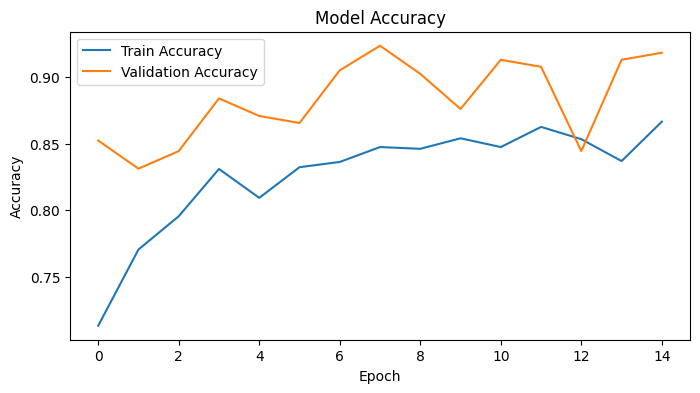

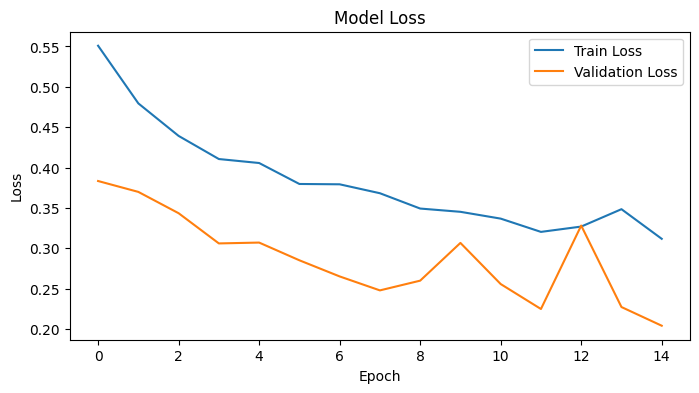

✅ Model saved as 'forest_fire_cnn_model_gray.h5'


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

base_path = "data/Forest Fire Dataset"
train_dir = os.path.join(base_path, "Training")
test_dir = os.path.join(base_path, "Testing")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    color_mode='grayscale',
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    color_mode='grayscale',
    class_mode='binary'
)

print("\nClass mapping:", train_generator.class_indices)

cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(64, 64, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),

    tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = cnn.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

cnn.save("forest_fire_cnn_model_gray.h5")
print("✅ Model saved as 'forest_fire_cnn_model_gray.h5'")

In [ ]:
loss, accuracy = cnn.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9275 - loss: 0.2040
Test Accuracy: 91.82%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

In [ ]:
import tensorflow as tf
from google.colab import files

model = tf.keras.models.load_model("forest_fire_cnn_model_gray.h5")

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_path = "data/Forest Fire Dataset"
test_dir = os.path.join(base_path, "Testing")

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    color_mode='grayscale'
)

print("\nClass mapping:", test_generator.class_indices)

Found 379 images belonging to 2 classes.

Class mapping: {'fire': 0, 'no fire': 1}


In [ ]:

y_pred_prob = model.predict(test_generator)


y_pred = (y_pred_prob > 0.5).astype("int32").flatten()


y_true = test_generator.classes

print("✅ Predictions completed!")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
✅ Predictions completed!


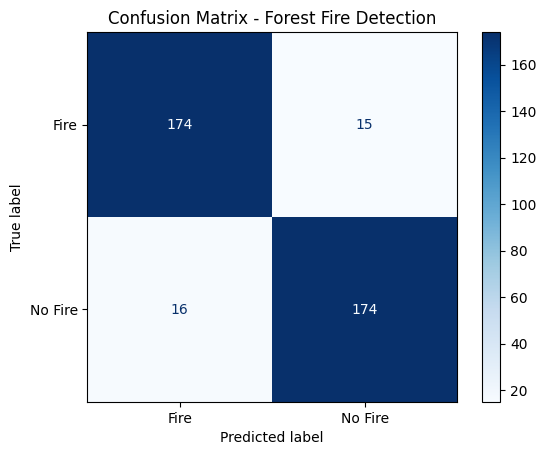


Classification Report:

              precision    recall  f1-score   support

        Fire       0.92      0.92      0.92       189
     No Fire       0.92      0.92      0.92       190

    accuracy                           0.92       379
   macro avg       0.92      0.92      0.92       379
weighted avg       0.92      0.92      0.92       379



In [ ]:
from sklearn.metrics import classification_report


cm = confusion_matrix(y_true, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fire", "No Fire"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Forest Fire Detection")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Fire", "No Fire"]))

In [ ]:
def send_email_alert(message):
    sender_email = "aljon9247@gmail.com"
    receiver_email = "blackyna8@gmail.com"
    password = "aigx ehmn yoxy mmum"

    subject = "🔥 Fire Alert Detected!"
    body = message

    msg = MIMEMultipart()
    msg["From"] = sender_email
    msg["To"] = receiver_email
    msg["Subject"] = subject
    msg.attach(MIMEText(body, "plain"))

    context = ssl.create_default_context()
    with smtplib.SMTP_SSL("smtp.gmail.com", 465, context=context) as server:
        server.login(sender_email, password)
        server.sendmail(sender_email, receiver_email, msg.as_string())

    print("📧 Email Alert Sent Successfully!")

✅ Trained model loaded successfully!

Please upload an image to predict:


Saving fire3.jpg to fire3 (1).jpg
Uploaded file: fire3 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


<IPython.core.display.Javascript object>

📧 Email Alert Sent Successfully!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


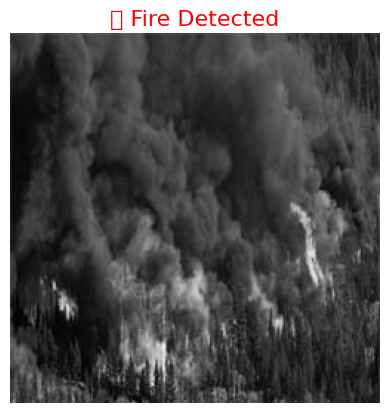

Prediction Score: 0.1947
Result: 🔥 Fire Detected


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files
import os
from IPython.display import display, Javascript, Audio

import smtplib, ssl
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

model_path = "forest_fire_cnn_model_gray.h5"
if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("✅ Trained model loaded successfully!")
else:
    print(f"❌ Error: Model file not found at {model_path}")
    print("Please ensure the model has been trained and saved.")
print("\nPlease upload an image to predict:")
uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]
print("Uploaded file:", uploaded_filename)
img = image.load_img(uploaded_filename, target_size=(64, 64), color_mode='grayscale')
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
if 'model' in locals() and model is not None:
    prediction = model.predict(img_array)[0][0]
    if prediction > 0.5:
        result = "No Fire Detected"
        color = 'green'
    else:
        result = "🔥 Fire Detected"
        color = 'red'

        display(Javascript('alert("🔥 ALERT: Fire Detected!")'))
        display(Audio(data=np.sin(2*np.pi*440*np.arange(44100)/44100).astype(np.float32),
                      rate=44100, autoplay=True))
        if result == "🔥 Fire Detected":
            send_email_alert("Warning! A forest fire has been detected in the input image.")

    plt.imshow(image.load_img(uploaded_filename, color_mode='grayscale').convert('RGBA'))
    plt.axis('off')
    plt.title(result, color=color, fontsize=16)
    plt.show()
    print(f"Prediction Score: {prediction:.4f}")
    print("Result:", result)
else:
    print("Model not loaded, cannot make a prediction.")